In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score,f1_score

In [49]:
data=pd.read_csv("/content/Training.csv")
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [50]:
print(data['Outcome'].value_counts())
print(data[	'Outcome'].value_counts(normalize=True))

Outcome
0    1500
1     960
Name: count, dtype: int64
Outcome
0    0.609756
1    0.390244
Name: proportion, dtype: float64


In [51]:
"""data.groupby('Outcome').apply(lambda x: x.sample(n=900))"""

"data.groupby('Outcome').apply(lambda x: x.sample(n=900))"

In [52]:
print(data['Outcome'].value_counts())
print(data[	'Outcome'].value_counts(normalize=True))

Outcome
0    1500
1     960
Name: count, dtype: int64
Outcome
0    0.609756
1    0.390244
Name: proportion, dtype: float64


(imbalanced) لتقليل

In [53]:
data.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [54]:
print(data['Outcome'].value_counts())
print(data[	'Outcome'].value_counts(normalize=True))

Outcome
0    1500
1     960
Name: count, dtype: int64
Outcome
0    0.609756
1    0.390244
Name: proportion, dtype: float64


In [55]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2460 entries, 0 to 2459
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               2460 non-null   int64  
 1   Glucose                   2460 non-null   int64  
 2   BloodPressure             2460 non-null   int64  
 3   SkinThickness             2460 non-null   int64  
 4   Insulin                   2460 non-null   int64  
 5   BMI                       2460 non-null   float64
 6   DiabetesPedigreeFunction  2460 non-null   float64
 7   Age                       2460 non-null   int64  
 8   Outcome                   2460 non-null   int64  
dtypes: float64(2), int64(7)
memory usage: 173.1 KB


In [56]:
cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
data[cols] = data[cols].replace(0, np.nan)

التخلص من القيمnull   في الاعمده  باستبدالها في  median  الوسيط

In [57]:
for col in ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']:
    data[col].fillna(data[col].median(), inplace=True)

/tmp/ipykernel_7999/3444283585.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[col].fillna(data[col].median(), inplace=True)


التخلص من ال outliers

In [58]:
cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'Age']

for col in cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    data[col]=np.where(data[col]>upper,upper,np.where(data[col]<lower,lower,data[col]))

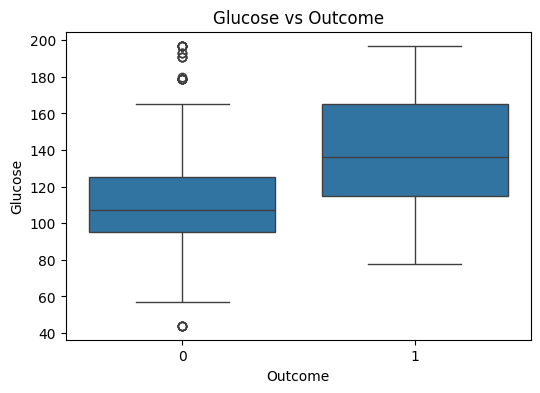

In [59]:
plt.figure(figsize=(6,4))
sns.boxplot(x=data["Outcome"], y=data["Glucose"])
plt.title("Glucose vs Outcome")
plt.show()

القاعده : المرضى عندهم جلوكوز اعلى Glucose
---
بالتالي : Glucos أقوى عامل




In [60]:
data[data["Glucose"] > 125]["Outcome"].mean()

np.float64(0.6118012422360248)

أكثر من %61
---
من الأشخاص الذين لديهم Glucose
---
أعلى من 125 كانوا مصابين

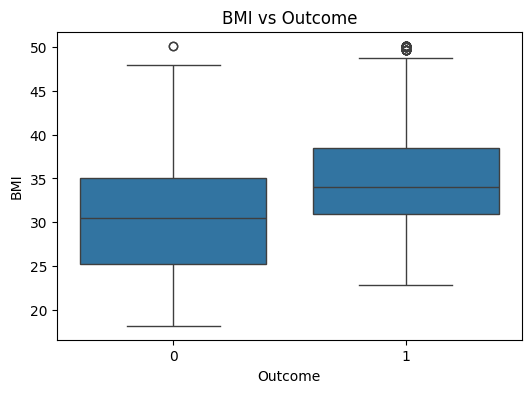

In [61]:
plt.figure(figsize=(6,4))
sns.boxplot(x="Outcome", y="BMI", data=data)
plt.title("BMI vs Outcome")
plt.show()

المرضى عندهم BMI أعلى
---
الفرق ليس قوي مثل Glucose بس واضح
---
من heatmap:
correlation ≈ 0.33

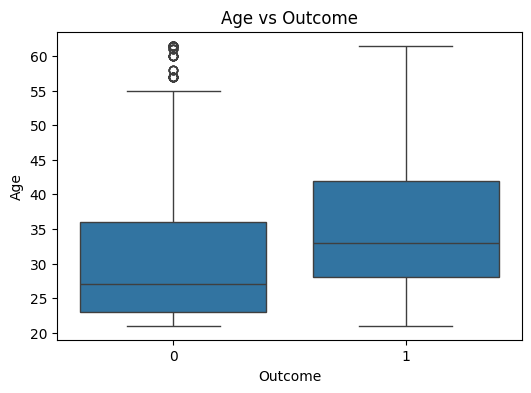

In [62]:
plt.figure(figsize=(6,4))
sns.boxplot(x="Outcome", y="Age", data=data)
plt.title("Age vs Outcome")
plt.show()

المرضى أعمارهم أعلى

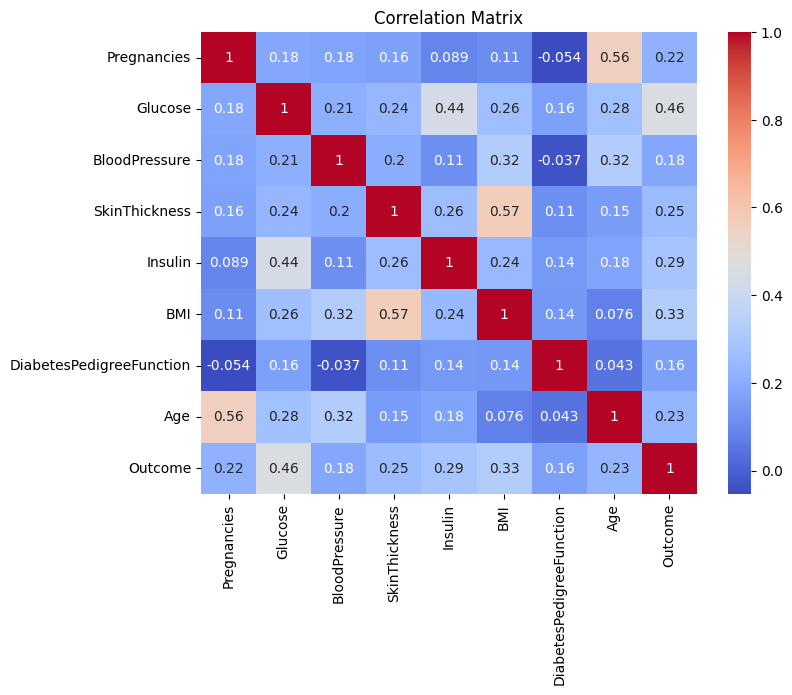

In [63]:
plt.figure(figsize=(8,6))
sns.heatmap(data.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

من heatmap: correlation
---
نلاحظ : Glucose (الأقوى)  <<  BMI + Age  <<  BMI  <<  Age (الأضعف)

بالتالي بناء على ذلك ننبني القواعد التاليه :

In [64]:
def expert_system(row):
    if row['Glucose'] > 125:
        return 1
    elif row['BMI'] > 35:
        return 1
    elif row['BMI'] > 30 and row['Age'] > 35:
        return 1
    else:
        return 0

In [65]:
X = data.drop("Outcome", axis=1)
y = data["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [66]:
y_pred = X_test.apply(expert_system, axis=1)

In [67]:
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)

print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)

Accuracy: 0.6158536585365854
Precision: 0.49666666666666665
Recall: 0.7967914438502673


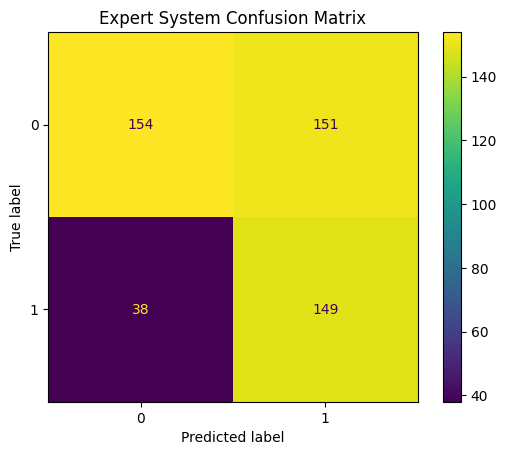

In [68]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.title("Expert System Confusion Matrix")
plt.show()

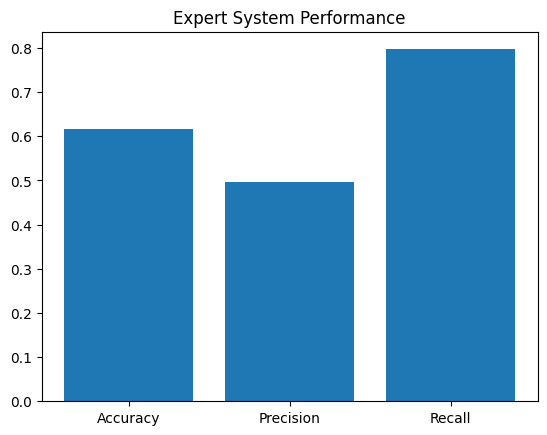

In [69]:
metrics = ["Accuracy", "Precision", "Recall"]
values = [acc, prec, rec]

plt.bar(metrics, values)
plt.title("Expert System Performance")
plt.show()

تم بناء نظام خبير باستخدام مجموعة من القواعد المستخلصة من تحليل البيانات،
---
، حيث تم الاعتماد بشكل أساسي على متغيرات
---
Glucose و BMI و Age.



أظهر النظام الخبير قدرة مقبولة على التنبؤ، حيث كان الجلوكوز العامل الأكثر تأثيرًا. ومع ذلك، فإن دقته أقل مقارنة بنماذج التعلم الآلي بسبب بساطة القواعد المستخدمة.

خوارزمية   Decision Tree

In [70]:
dt = DecisionTreeClassifier(
    class_weight="balanced",
    criterion="gini",
    max_depth=5,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42
)

Random Forest

In [71]:
rf = RandomForestClassifier(
    class_weight="balanced",
    n_estimators=100,
    max_depth=5,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="sqrt",
    bootstrap=True,
    random_state=42
)

 Logistic Regression

In [72]:
lr = LogisticRegression(class_weight="balanced",
  max_iter=1000)

تدريب الموديلات  الثلاثه :

In [73]:
dt.fit(X_train, y_train)


DecisionTreeClassifier(class_weight='balanced', max_depth=5, random_state=42)

In [74]:
rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=5, random_state=42)

In [75]:
lr.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

التنبؤ :

In [76]:
y_pred_dt = dt.predict(X_test)

In [77]:
y_pred_rf = rf.predict(X_test)

In [78]:
y_pred_lr = lr.predict(X_test)

 التقييم :

In [79]:
def evaluate(y_test, y_pred, name):
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print(f"--- {name} ---")
    print("Accuracy:", acc)
    print("Precision:", prec)
    print("Recall:", rec)
    print("F1-score:", f1)
    print()

    return acc, prec, rec,f1

In [80]:
acc_dt, prec_dt, rec_dt,f1_dt= evaluate(y_test, y_pred_dt, "Decision Tree")
acc_rf, prec_rf, rec_rf ,f1_rf = evaluate(y_test, y_pred_rf, "Random Forest")
acc_lr, prec_lr, rec_lr ,f1_lr = evaluate(y_test, y_pred_lr, "Logistic Regression")

--- Decision Tree ---
Accuracy: 0.7926829268292683
Precision: 0.6615969581749049
Recall: 0.93048128342246
F1-score: 0.7733333333333333

--- Random Forest ---
Accuracy: 0.8333333333333334
Precision: 0.723404255319149
Recall: 0.9090909090909091
F1-score: 0.8056872037914692

--- Logistic Regression ---
Accuracy: 0.7073170731707317
Precision: 0.6102564102564103
Recall: 0.6363636363636364
F1-score: 0.6230366492146597



 رسم المقارنة

In [81]:
models = ["Decision Tree", "Random Forest", "Logistic Regression"]

accuracies = [acc_dt, acc_rf, acc_lr]
precisions = [prec_dt, prec_rf, prec_lr]
recalls = [rec_dt, rec_rf, rec_lr]

1.   رسم Accuracy

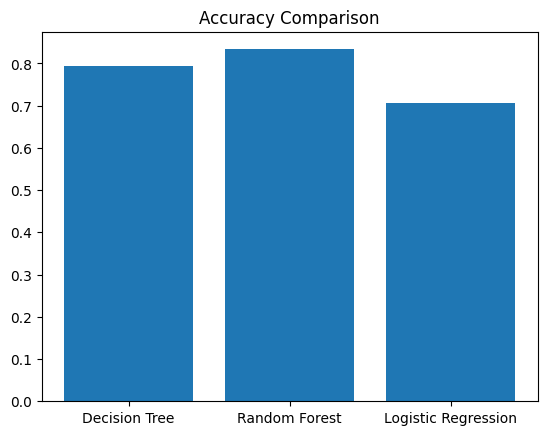

In [82]:
plt.figure()
plt.bar(models, accuracies)
plt.title("Accuracy Comparison")
plt.show()

2. رسم Precision

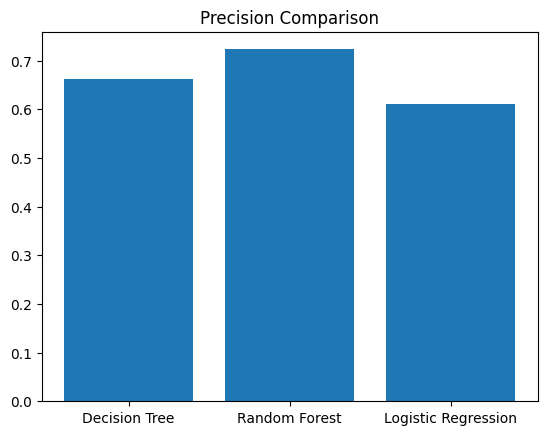

In [83]:
plt.figure()
plt.bar(models, precisions)
plt.title("Precision Comparison")
plt.show()

3. رسم Recall

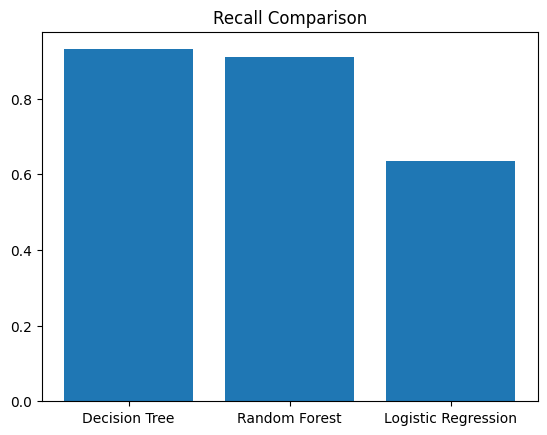

In [84]:
plt.figure()
plt.bar(models, recalls)
plt.title("Recall Comparison")
plt.show()

In [85]:
train_pred = rf.predict(X_train)
test_pred = rf.predict(X_test)

print("RF Training Accuracy:", accuracy_score(y_train, train_pred))
print("RF Testing Accuracy:", accuracy_score(y_test, test_pred))

RF Training Accuracy: 0.845020325203252
RF Testing Accuracy: 0.8333333333333334


In [86]:
train_pred = dt.predict(X_train)
test_pred = dt.predict(X_test)

print("DT Training Accuracy:", accuracy_score(y_train, train_pred))
print("DT Testing Accuracy:", accuracy_score(y_test, test_pred))

DT Training Accuracy: 0.7997967479674797
DT Testing Accuracy: 0.7926829268292683


In [87]:
train_pred = lr.predict(X_train)
test_pred = lr.predict(X_test)

print("LR Training Accuracy:", accuracy_score(y_train, train_pred))
print("LR Testing Accuracy:", accuracy_score(y_test, test_pred))

LR Training Accuracy: 0.7347560975609756
LR Testing Accuracy: 0.7073170731707317


Best Parameters:,grid_model.best_params_
Best Score: 0.990344996835484
Precision: 1.0
Recall: 0.9946524064171123
F1-Score: 0.9973190348525469
Accuracy: 0.9979674796747967
Confusion Matrix:
 [[305   0]
 [  1 186]]


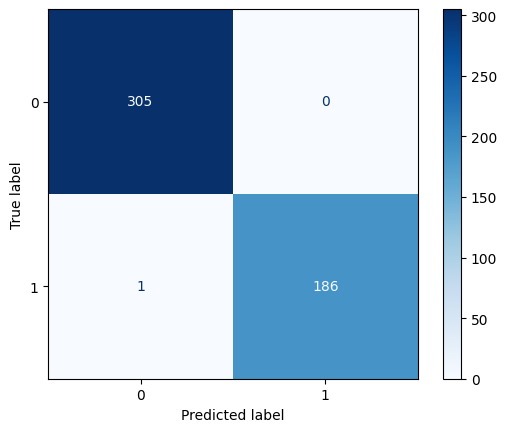

In [88]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, \
            accuracy_score, ConfusionMatrixDisplay,  precision_score,\
            recall_score, f1_score, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier


X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(0)
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42 )

grid_parameters ={
    'n_estimators': [50, 100],
    'learning_rate': [0.1, 0.01, 0.2],
    'max_depth': [3, 4, 5]
}


grid_model = GridSearchCV(
    estimator=XGBClassifier(random_state=0),
    param_grid=grid_parameters,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid_model.fit(X_train, y_train)
print("Best Parameters:,grid_model.best_params_")
print("Best Score:", grid_model.best_score_)
y_pred = grid_model.predict(X_test)

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)

print("Precision:", precision)
print("Recall:", recall)
print("F1-Score:", f1)
print("Accuracy:", acc)

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1])
disp.plot(cmap="Blues")
plt.show()

In [89]:
# أفضل موديل من GridSearch
best_model = grid_model.best_estimator_

# التنبؤ
train_pred = best_model.predict(X_train)
test_pred = best_model.predict(X_test)

# المقارنة
print("GS Training Accuracy:", accuracy_score(y_train, train_pred))
print("GS Testing Accuracy:", accuracy_score(y_test, test_pred))

GS Training Accuracy: 1.0
GS Testing Accuracy: 0.9979674796747967


In [90]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(best_model, X, y, cv=5)
print("CV Accuracy:", scores.mean())

CV Accuracy: 0.9991869918699188


هون لمعرفة هل فيه Overfiting  لمقارنة نتائج التريننج بالتيست

لا يوجد overfitting واضح في النماذج، حيث أن الفرق بين دقة التدريب والاختبار صغير في جميع الحالات.

تم استخدام ثلاث خوارزميات تعلم آلي وهي
---
Decision Tree و Random Forest و Logistic Regression
---
للتنبؤ بمرض السكري.


أظهر نموذج Random Forest
---
أفضل أداء من حيث الدقة،
---
يليه Decision Tree،
---
ثم Logistic Regression.





عند مقارنة النماذج مع النظام الخبير، تبين أن نماذج التعلم الآلي حققت دقة أعلى، وذلك لقدرتها على اكتشاف الأنماط المعقدة داخل البيانات.

يعتبر Random Forest النموذج الأفضل في هذه الحالة، بينما يوفر النظام الخبير تفسيرًا بسيطًا لكنه أقل دقة.

In [91]:
import joblib

joblib.dump(dt, "decision_tree_model.pkl")
joblib.dump(rf, "random_forest_model.pkl")
joblib.dump(lr, "logistic_regression_model.pkl")
joblib.dump(best_model, "gboost_model.pkl")

['gboost_model.pkl']

لحفظ الموديلات اللي تدربت كـ ملفات على شكل .pkl

In [92]:
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
medians = data[zero_cols].median()

joblib.dump(medians, "medians.pkl")

['medians.pkl']

لحفظ قيم الـ median اللي استخدمت في تنظيف البيانات